# Multi-modal RAG with LangChain

## SetUp

Install the dependencies you need to run the notebook.

In [ ]:
# for linux
# !apt-get install poppler-utils tesseract-ocr libmagic-dev

# for mac
# !brew install poppler tesseract libmagic

In [1]:
%pip install -Uq "unstructured[all-docs]" pillow lxml pillow
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import os

# keys for the services we will use

os.environ["MOONSHOT_API_KEY"]=""
os.environ["LANGCHAIN_API_KEY"] = ""
os.environ["LANGCHAIN_TRACING_V2"] = "true"


## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [2]:
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = output_path + 'attention.pdf'

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [3]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [5]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements

In [ ]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'ceba98e3-85c8-4d31-810f-90ba503ed344',
 'text': 'Scaled Dot-Product Attention  Multi-Head Attention ',
 'metadata': {'detection_class_prob': 0.8599750995635986,
  'coordinates': {'points': ((410.50833333333327, 197.0675599999999),
    (410.50833333333327, 669.311279296875),
    (1311.755126953125, 669.311279296875),
    (1311.755126953125, 197.0675599999999)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2024-10-09T21:49:12',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [33]:
from unstructured.chunking.title import chunk_by_title
from unstructured.documents.elements import (
    NarrativeText, Text, Title, ListItem, Header, Footer, PageNumber,
    Image, Table, TableChunk, CompositeElement
)

tables = []
text_elements = []   # 收集原始文本元素（碎片）
images_b64 = []

def classify_chunk(chunk):
    chunk_type = type(chunk).__name__
    
    if chunk_type in ("Image",):
        b64 = getattr(chunk.metadata, "image_base64", None) \
           or getattr(chunk, "image_base64", None)
        if b64:
            images_b64.append(b64)
    
    elif chunk_type in ("Table", "TableChunk"):
        tables.append(chunk)
    
    elif chunk_type in ("CompositeElement",):
        # 递归拆解（如果你前面用了 chunking，但这里我们没用）
        inner = getattr(chunk.metadata, "orig_elements", []) \
             or getattr(chunk, "elements", [])
        for el in inner:
            classify_chunk(el)
    
    elif chunk_type in ("NarrativeText", "Text", "Title", "ListItem"):
        # 只保留有实质内容的文本元素，过滤页眉页脚页码
        content = getattr(chunk, "text", None)
        if content and len(content.strip()) > 10:
            text_elements.append(chunk)
    
    # 显式丢弃：Header, Footer, PageNumber 等噪声
    # 什么都不做，自然丢弃

# 单次遍历
for chunk in chunks:
    classify_chunk(chunk)

# ========== 关键：把碎片合并成完整段落 ==========
# 对纯文本元素做 chunking，自动按标题合并相邻文本
text_chunks = chunk_by_title(
    text_elements,
    max_characters=10000,
    combine_text_under_n_chars=2000,
    new_after_n_chars=6000,
)

# 提取字符串，这才是真正用于摘要的完整文本
texts = [str(chunk) for chunk in text_chunks]

# 表格提取 HTML（不变）
tables_html = [table.metadata.text_as_html for table in tables if hasattr(table.metadata, "text_as_html")]

In [34]:
print(f"原始碎片数量: {len(text_elements)}")
print(f"合并后文本块数量: {len(texts)}")
print("\n=== 前 3 个文本块 ===")
for i, t in enumerate(texts[:3]):
    print(f"\n--- 块 {i} ({len(t)} 字) ---")
    print(t[:300] + "..." if len(t) > 300 else t)

原始碎片数量: 162
合并后文本块数量: 12

=== 前 3 个文本块 ===

--- 块 0 (2831 字) ---
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

Attention Is All You Need

Ashish Vaswani∗

Google Brain

avaswani@google.com

Noam Shazeer∗

Google Brain noam@google.com

N...

--- 块 1 (3758 字) ---
1 Introduction

Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numer...

--- 块 2 (2064 字) ---
3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder t

#### Check what the images look like

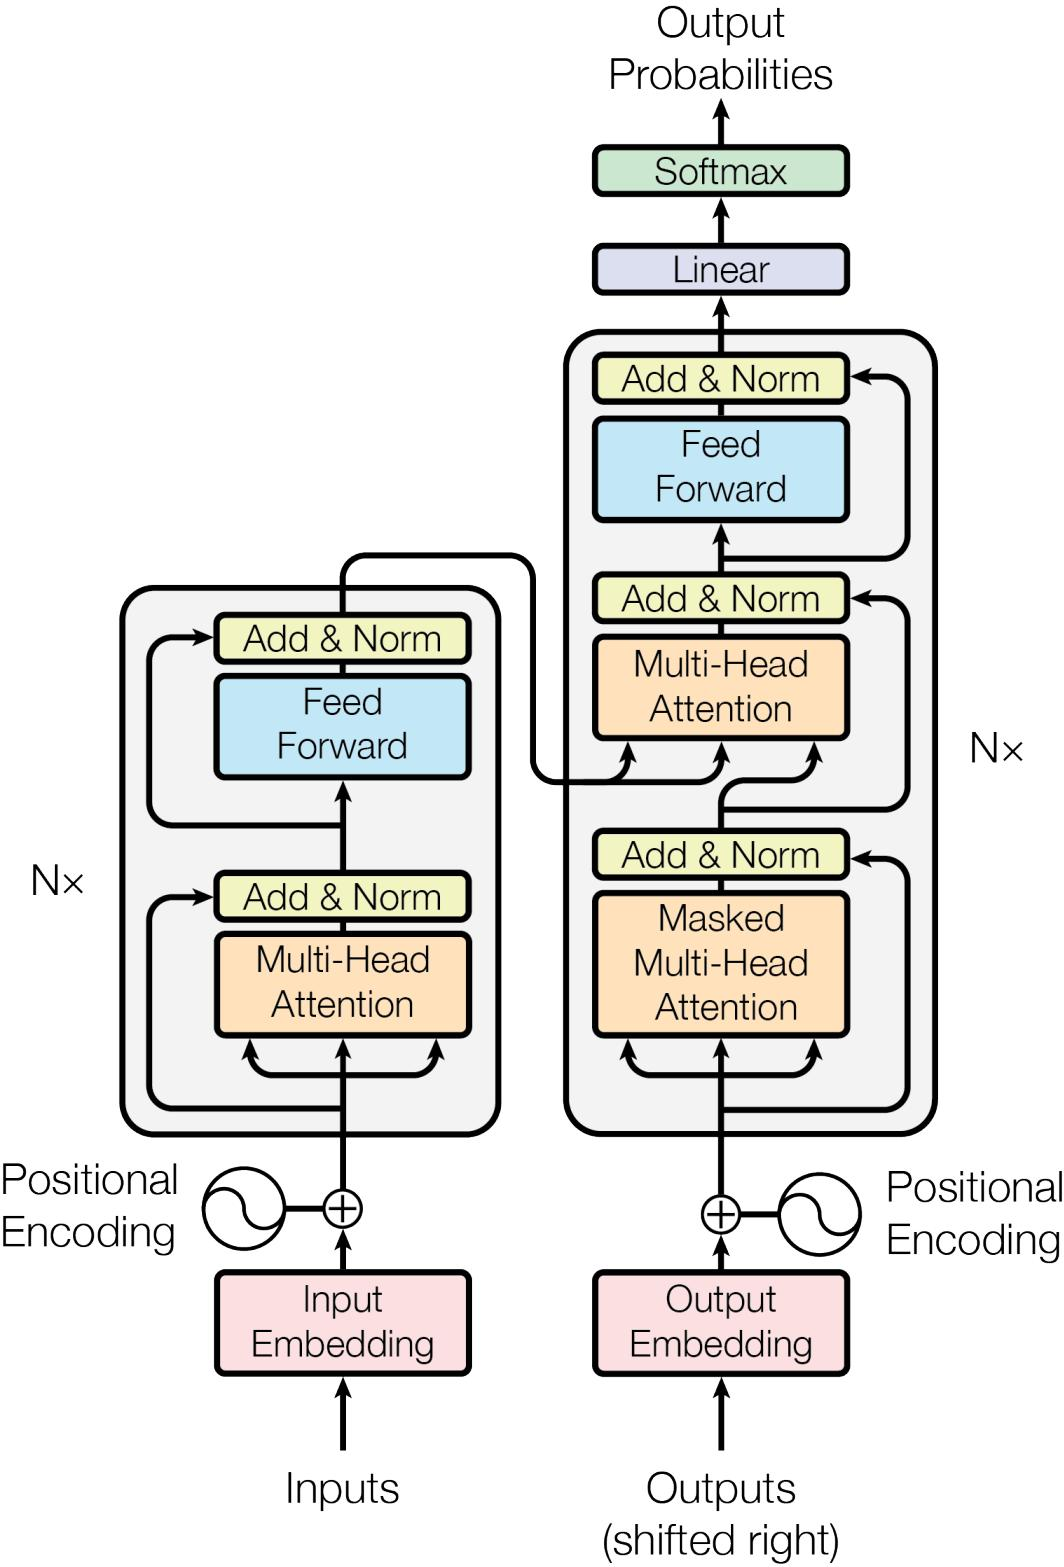

In [35]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images_b64[0])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [11]:
import os
import base64

from openai import OpenAI

In [12]:
%pip install langchain-moonshot

Note: you may need to restart the kernel to use updated packages.


In [22]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [36]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
llm = ChatOpenAI(
    model="kimi-k2.6",
    api_key=os.getenv("MOONSHOT_API_KEY"), # 直接写这里，或从环境变量读取
    base_url="https://api.moonshot.cn/v1",
)
model = llm
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [29]:
print(f"texts 数量: {len(texts)}")
print(f"tables 数量: {len(tables)}")

# 先不用 batch，单条测试 API 是否通
if texts:
    test = summarize_chain.invoke(texts[0])
    print("单条结果:", test)

texts 数量: 221
tables 数量: 4
单条结果: 3


In [37]:
print("=== 前 5 个元素的类型和内容 ===")
for i, t in enumerate(texts[:5]):
    print(f"\n--- 第 {i} 个 ---")
    print("类型:", type(t).__name__)
    print("repr:", repr(t))
    print("str():", str(t))
    if hasattr(t, "text"):
        print("属性 .text:", t.text)
    if hasattr(t, "metadata") and hasattr(t.metadata, "page_number"):
        print("页码:", t.metadata.page_number)

=== 前 5 个元素的类型和内容 ===

--- 第 0 个 ---
类型: str
repr: 'Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗\n\nGoogle Brain noam@google.com\n\nNiki Parmar∗\n\nGoogle Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, b

In [40]:
print(f"表格 HTML 数量: {len(tables_html)}")

if not tables_html:
    print("⚠️ 没提取到表格 HTML，检查以下可能：")
    print("  1. pip install 'unstructured[pdf]' 是否完整安装（含 pikepdf, pdfplumber）")
    print("  2. PDF 里的表格是图片扫描件而非文本型表格")
    print("  3. 尝试加参数: pdf_infer_table_structure=True")
else:
    for i, html in enumerate(tables_html):
        print(f"\n--- 表格 {i} ({len(html)} 字符) ---")
        # 预览前 500 字符，保留标签结构
        preview = html[:500].replace("\n", " ")
        print(preview + ("..." if len(html) > 500 else ""))
        
        # 简单统计行列（数 <tr> 和 <td>）
        rows = html.count("<tr")
        cells = html.count("<td")
        print(f"[统计] 约 {rows} 行, {cells} 单元格")

表格 HTML 数量: 4

--- 表格 0 (449 字符) ---
<table><tr><td>Layer Type</td><td>Complexity per Layer</td><td>Sequential Operations</td><td>Maximum Path Length</td></tr><tr><td>Self-Attention</td><td>O(n? - d)</td><td>O(1)</td><td>O(1)</td></tr><tr><td>Recurrent</td><td>O(n - d?)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k-n-d?)</td><td>O(1)</td><td>O(log, (7))</td></tr><tr><td>Self-Attention (restricted)</td><td>O(r-n-d)</td><td>O(1)</td><td>O(n/r)</td></tr></table>
[统计] 约 5 行, 20 单元格

--- 表格 1 (1003 字符) ---
<table><tr><td>Model</td><td>EN-DE</td><td>BLEU EN-FR</td><td>Training EN-DE</td><td>Cost (FLOPs) EN-FR</td></tr><tr><td colspan="5">ByteNet [18] 23.75</td></tr><tr><td>Deep-Att + PosUnk [39]</td><td/><td>39.2</td><td/><td>1.0 - 102°</td></tr><tr><td>GNMT + RL [38]</td><td>24.6</td><td>39.92</td><td>2.3-10!9</td><td>1.4-10?°</td></tr><tr><td>ConvS2S [9]</td><td>25.16</td><td>40.46</td><td>9.6-10'8</td><td>1.5. 107°</td></tr><tr><td>MoE [32]</td><td>26.03</td><td>40.

In [41]:
import re

def fix_table_html(html: str) -> str:
    """修复 unstructured 表格解析中的常见乱码"""
    
    # 1. 修复乘号和上标（基于 Attention 论文的已知表格内容）
    fixes = [
        # 复杂度表格 (Table 1)
        (r'O\(n\? - d\)', 'O(n² · d)'),
        (r'O\(n - d\?\)', 'O(n · d²)'),
        (r'O\(k-n-d\?\)', 'O(k · n · d²)'),
        (r'O\(log, \(7\)\)', 'O(log_k(n))'),  # 或 O(log_k(n))
        (r'O\(n/r\)', 'O(n/r)'),
        
        # 训练成本表格 (Table 2) - 科学计数法
        (r'1\.0 - 102°', '1.0 · 10²⁰'),
        (r'1\.4-10\?°', '1.4 · 10²⁰'),
        (r'2\.3-10!9', '2.3 · 10¹⁹'),
        (r'2\.0-10!9', '2.0 · 10¹⁹'),
        (r'9\.6-10\'8', '9.6 · 10¹⁸'),
        (r'1\.5\. 107°', '1.5 · 10¹⁹'),
        
        # 模型变体表格 (Table 3) - 维度符号
        (r'\bAmodel\b', 'd_model'),
        (r'\bgg\b', 'd_ff'),
        (r'\bdy,\b', 'd_k'),      # 第一个 d_k
        (r'\bdy,\b', 'd_v'),      # 第二个 d_v（如果同一行有两个）
        (r'\bParop\b', 'P_drop'),  # dropout
        (r'\bEls\b', 'P_ls'),      # label smoothing
        (r'\|\s*6\s*\|', '| 6 |'), # 清理 N=6 的格式
        (r'64 =', '64'),
        (r'=\s*64', '64'),
        
        # 通用清理
        (r'-\s*10[\'!°?]', ' · 10'),  # 统一乘号格式
    ]
    
    for pattern, replacement in fixes:
        html = re.sub(pattern, replacement, html)
    
    # 2. 清理空单元格的自闭合标签（unstructured 有时会生成 <td/>）
    html = html.replace('<td/>', '<td></td>')
    
    return html

# 应用
tables_html_fixed = [fix_table_html(html) for html in tables_html]

# 验证
for i, html in enumerate(tables_html_fixed):
    print(f"\n--- 表格 {i} 修复后预览 ---")
    # 提取纯文本看看效果
    text_only = re.sub(r'<[^>]+>', ' ', html)
    text_only = re.sub(r'\s+', ' ', text_only).strip()
    print(text_only[:300])


--- 表格 0 修复后预览 ---
Layer Type Complexity per Layer Sequential Operations Maximum Path Length Self-Attention O(n² · d) O(1) O(1) Recurrent O(n · d²) O(n) O(n) Convolutional O(k · n · d²) O(1) O(log_k(n)) Self-Attention (restricted) O(r-n-d) O(1) O(n/r)

--- 表格 1 修复后预览 ---
Model EN-DE BLEU EN-FR Training EN-DE Cost (FLOPs) EN-FR ByteNet [18] 23.75 Deep-Att + PosUnk [39] 39.2 1.0 · 10²⁰ GNMT + RL [38] 24.6 39.92 2.3 · 10¹⁹ 1.4 · 10²⁰ ConvS2S [9] 25.16 40.46 9.6 · 10¹⁸ 1.5 · 10¹⁹ MoE [32] 26.03 40.56 2.0 · 10¹⁹ 1.2- 107° Deep-Att + PosUnk Ensemble [39] 40.4 8.0 - 102° G

--- 表格 2 修复后预览 ---
N d_model d_ff h dy, dy, P_drop P_ls train steps | PPL (dev) BLEU (dev) params x 106 base | 6 512 2048 8 64 64 0.1 0.1 100K | 4.92 25.8 65 (A) 1 512 512 5.29 24.9 4 128 128 5.00 25.5 16 32 32 4.91 25.8 32 =616 16 5.01 25.4 (B) 16 5.16 25.1 58 32 5.01 25.4 60 (C) 2 6.11 23.7 36 4 5.19 25.3 50 8 4.88 

--- 表格 3 修复后预览 ---
Zhu et al. (2013) [40] Dyer et al. (2016) [8] WSJ only, discriminative WSJ only, disc

In [38]:

# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})



In [39]:
text_summaries

['"Attention Is All You Need" by Vaswani et al. introduces the Transformer, a novel sequence transduction architecture based entirely on attention mechanisms, eliminating recurrence and convolutions. The model achieves superior results with greater parallelizability and shorter training times, scoring 28.4 BLEU on WMT 2014 English-to-German and establishing a new single-model state-of-the-art of 41.8 BLEU on English-to-French after just 3.5 days on eight GPUs. It also generalizes successfully to English constituency parsing. The authors contributed equally to this work presented at NIPS 2017.',
 'The text introduces the Transformer, a sequence transduction model that replaces recurrence and convolution with entirely attention-based mechanisms, specifically self-attention. While recurrent models process sequences sequentially, precluding parallelization, and convolutional models require linear or logarithmic operations to relate distant positions, the Transformer computes global depende

In [42]:
table_summaries = summarize_chain.batch(tables_html_fixed, {"max_concurrency": 3})
table_summaries

['The table compares neural network layer types across computational complexity, sequential operations, and maximum path length. Self-attention has O(n²·d) complexity with O(1) sequential operations and constant maximum path length. Recurrent layers have O(n·d²) complexity but require O(n) sequential operations and have O(n) path length. Convolutional layers have O(k·n·d²) complexity with O(1) sequential operations and O(log_k(n)) path length. Restricted self-attention reduces complexity to O(r·n·d), maintains O(1) sequential operations, but has an increased path length of O(n/r).',
 'The table compares neural machine translation models on English-to-German (EN-DE) and English-to-French (EN-FR) BLEU scores and training computational cost (FLOPs). Transformer models outperform previous individual and ensemble architectures, with Transformer (big) achieving the highest scores (28.4 EN-DE, 41.8 EN-FR) surpassing models like GNMT + RL, ConvS2S, and MoE, while requiring competitive training

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [ ]:
%pip install -Uq langchain_openai

Note: you may need to restart the kernel to use updated packages.


In [54]:
import time
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("MOONSHOT_API_KEY"),
    base_url="https://api.moonshot.cn/v1",
)

def summarize_image_with_retry(b64: str, max_retries=3) -> str:
    """单条请求，带指数退避重试"""
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model="kimi-k2.6",
                temperature=1,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": "Describe this academic figure in one sentence, focusing on what it illustrates."},
                            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                        ],
                    }
                ],
            )
            return resp.choices[0].message.content
        
        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                wait = 2 ** attempt  # 1s, 2s, 4s
                print(f"Rate limit, retrying in {wait}s... ({attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                return f"[ERROR: {e}]"
    
    return "[ERROR: Max retries exceeded]"

# 顺序执行，每条间隔 1 秒
image_summaries = []
for i, b64 in enumerate(images_b64):
    print(f"Processing image {i+1}/{len(images_b64)}...")
    summary = summarize_image_with_retry(b64)
    image_summaries.append(summary)
    time.sleep(1)  # ← 关键：主动降速，避免 429

print(f"✅ 完成 {len(image_summaries)} 张图片摘要")

Processing image 1/7...
Processing image 2/7...
Processing image 3/7...
Processing image 4/7...
Processing image 5/7...
Processing image 6/7...
Processing image 7/7...
✅ 完成 7 张图片摘要


In [51]:
image_summaries

NameError: name 'image_summaries' is not defined

In [50]:
print(image_summaries[1])

NameError: name 'image_summaries' is not defined

## Load data and summaries to vectorstore

### Create the vectorstore

In [55]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.embeddings import HuggingFaceEmbeddings  # ← 本地模型，零 API Key
# 本地 Embedding（首次自动下载，约 100MB）
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=embeddings,
    persist_directory="./chroma_db",  # 数据落盘，重启不丢
)

store = InMemoryStore()
id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### Load the summaries and link the to the original data

In [56]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables_html_fixed]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables_html_fixed)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images_b64]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images_b64)))

### Check retrieval

In [57]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)

In [58]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

<table><tr><td>Zhu et al. (2013) [40] Dyer et al. (2016) [8]</td><td>WSJ only, discriminative WSJ only, discriminative</td><td>90.4 91.7</td></tr><tr><td>Transformer (4 layers)</td><td>WSJ only, discriminative</td><td>91.3</td></tr><tr><td>Zhu et al. (2013) [40]</td><td>semi-supervised</td><td>91.3</td></tr><tr><td>Vinyals (2014) [37] Transformer (4 layers)</td><td>semi-supervised semi-supervised</td><td>92.7</td></tr></table>

--------------------------------------------------------------------------------
[30] Ofir Press and Lior Wolf. Using the output embedding to improve language models. arXiv preprint arXiv:1608.05859, 2016.

[31] Rico Sennrich, Barry Haddow, and Alexandra Birch. Neural machine translation of rare words with subword units. arXiv preprint arXiv:1508.07909, 2015.

[32] Noam Shazeer, Azalia Mirhoseini, Krzysztof Maziarz, Andy Davis, Quoc Le, Geoffrey Hinton, and Jeff Dean. Outrageously large neural networks: The sparsely-gated mixture-of-experts layer. arXiv preprint

## RAG pipeline

In [59]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from base64 import b64decode
import os

# ========== 1. 文档分类（兼容字符串存储） ==========
def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception:
            text.append(doc)
    return {"images": b64, "texts": text}

# ========== 2. Prompt 构建（修复 .text 问题） ==========
def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    # 兼容字符串和 Document 对象
    context_text = ""
    for text_element in docs_by_type["texts"]:
        if hasattr(text_element, "text"):
            context_text += text_element.text
        else:
            context_text += str(text_element)

    prompt_template = f"""Answer the question based only on the following context, which can include text, tables, and images.
Context: {context_text}
Question: {user_question}"""

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            })

    return ChatPromptTemplate.from_messages([HumanMessage(content=prompt_content)])

# ========== 3. LLM（改成 Moonshot） ==========
llm = ChatOpenAI(
    model="kimi-k2.6",
    api_key=os.getenv("MOONSHOT_API_KEY"),
    base_url="https://api.moonshot.cn/v1",
    temperature=1,
)

# ========== 4. 组装 Chain ==========
chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | llm
    | StrOutputParser()
)

# 带溯源版本
chain_with_sources = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnablePassthrough().assign(
        response=(RunnableLambda(build_prompt) | llm | StrOutputParser())
    )
)

In [60]:
response = chain.invoke(
    "What is the attention mechanism?"
)

print(response)

Based on the provided diagrams, the **attention mechanism** is a method that allows a model to dynamically focus on different parts of an input sequence by computing relationships between all positions using **Query (Q)**, **Key (K)**, and **Value (V)** vectors.

Specifically, the context illustrates the following:

**Scaled Dot-Product Attention Computation**
As shown in the flowchart, the mechanism takes Q, K, and V as inputs and processes them through a pipeline:
1.  **MatMul**: Computes the dot product between Q and K.
2.  **Scale**: Scales the result.
3.  **Mask (opt.)**: Applies an optional masking step.
4.  **SoftMax**: Converts the scores into attention weights (probabilities).
5.  **MatMul**: Multiplies these weights by V to produce the final output.

**Multi-Head Attention**
The first diagram shows that this process can be run in parallel across multiple "heads" (denoted by **h**). Each head independently applies its own linear transformations to Q, K, and V, performs scaled 

Response: Based on the provided context, **multi-head attention** is a mechanism that performs attention in parallel across multiple “heads” rather than using a single attention function. Specifically:

*   **Projections:** The queries (**Q**), keys (**K**), and values (**V**) are linearly projected *h* times using different, learned linear projections into lower-dimensional spaces—projecting Q and K to dimension *dₖ* and V to dimension *dᵥ*.
*   **Parallel attention:** Each projected version of Q, K, and V is fed into its own **Scaled Dot-Product Attention** block (as shown in the figure, where V, K, and Q each pass through a linear layer into *h* parallel attention blocks).
*   **Concatenation and final projection:** The *dᵥ*-dimensional outputs from all *h* heads are concatenated together and then projected once more by a parameter matrix **W**ᴼ to produce the final values.
*   **Purpose:** This allows the model to jointly attend to information from different representation subspace

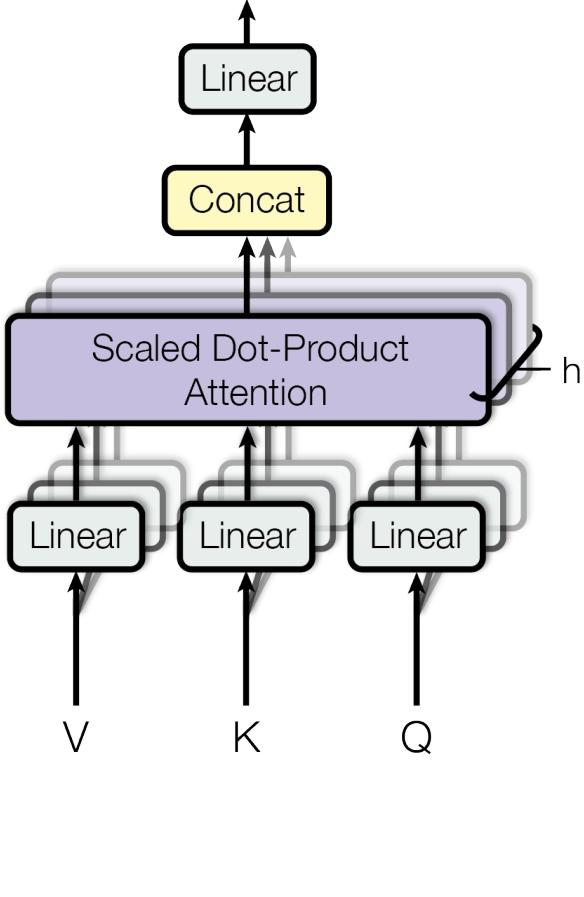

In [62]:
response = chain_with_sources.invoke("What is multihead?")

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    # text 是字符串，直接打印
    print(text)
    print("\n" + "-"*50 + "\n")

for image in response['context']['images']:
    display_base64_image(image)

## References

- [LangChain Inspiration](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev)
- [Multivector Storage](https://python.langchain.com/docs/how_to/multi_vector/)